In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys

# 1) Go to /content and nuke any old clones
%cd /content
!rm -rf mixture-of-experts-project mixture_of_experts_project

# 2) Clone the *course* repo with the dash name
!git clone https://github.com/moe-project-uu/mixture-of-experts-project.git

# 3) cd into it and checkout your branch
%cd /content/mixture-of-experts-project
!git checkout -f arokah
!git branch   # this should show "* arokah"

# 4) Install deps into THIS Colab Python + editable project
!{sys.executable} -m pip install -U pip setuptools wheel
!{sys.executable} -m pip install -r requirements.txt
!{sys.executable} -m pip install -e .

# 5) Make sure Python can see src/moe
SRC_DIR = os.path.join(os.getcwd(), "src")
if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)

import moe
print("Imported moe from:", moe.__file__)


ValueError: mount failed

In [2]:
import os
CKPT_ROOT = "/content/drive/MyDrive/moe_project/checkpoints"
os.makedirs(CKPT_ROOT, exist_ok=True)
print("CKPT_ROOT =", CKPT_ROOT)


CKPT_ROOT = /content/drive/MyDrive/moe_project/checkpoints


### Train dense model
result: /content/drive/MyDrive/moe_project/checkpoints/Dense/E50/
    summary.json
    model.pt
    metrics.pt

In [3]:
#Note 512 is default width for dense model
#E50
!python scripts/train_cifar10.py \
    --FF_layer Dense \
    --epochs 50 \
    --ff_width 512 \
    --batch_size 128 \
    --ckpt_root "{CKPT_ROOT}"


100% 170M/170M [00:01<00:00, 102MB/s]
dataloaders metadata: {'mean': (0.4914, 0.4822, 0.4465), 'std': (0.247, 0.2435, 0.2616), 'num_classes': 10, 'sizes': {'train': 45000, 'val': 5000, 'test': 10000}}
Epoch 1/50: 100% 352/352 [00:07<00:00, 44.94it/s]
Epoch 001/50 | train_loss=1.6246 train_acc=40.09% | val_loss=1.4477 val_acc=52.30%
Saved checkpoint: Dense val_acc=52.30%
Epoch 2/50: 100% 352/352 [00:05<00:00, 62.93it/s]
Epoch 002/50 | train_loss=1.1035 train_acc=61.20% | val_loss=1.1284 val_acc=60.58%
Saved checkpoint: Dense val_acc=60.58%
Epoch 3/50: 100% 352/352 [00:05<00:00, 62.70it/s]
Epoch 003/50 | train_loss=0.8389 train_acc=71.41% | val_loss=1.1006 val_acc=63.54%
Saved checkpoint: Dense val_acc=63.54%
Epoch 4/50: 100% 352/352 [00:05<00:00, 62.70it/s]
Epoch 004/50 | train_loss=0.6724 train_acc=77.31% | val_loss=0.7403 val_acc=74.26%
Saved checkpoint: Dense val_acc=74.26%
Epoch 5/50: 100% 352/352 [00:05<00:00, 63.02it/s]
Epoch 005/50 | train_loss=0.5680 train_acc=80.97% | val_loss=

### Train softmoe
result: /content/drive/MyDrive/moe_project/checkpoints/SoftMoE/E50-X8/
    summary.json
    model.pt
    metrics.pt


In [13]:
#8 experts, 64 hidden width (0.125 * 512 = 64)
#E50-X8
!python scripts/train_cifar10.py \
    --FF_layer SoftMoE \
    --epochs 50 \
    --batch_size 128 \
    --num_experts 8 \
    --hidden_mult 0.125 \
    --temperature 1.0 \
    --softmoe_load_balance True \
    --softmoe_load_balance_coef 0.2 \
    --dropout_p 0.1 \
    --ckpt_root "{CKPT_ROOT}"


dataloaders metadata: {'mean': (0.4914, 0.4822, 0.4465), 'std': (0.247, 0.2435, 0.2616), 'num_classes': 10, 'sizes': {'train': 45000, 'val': 5000, 'test': 10000}}
Epoch 1/50: 100% 352/352 [00:08<00:00, 43.03it/s]
Epoch 001/50 | train_loss=1.6956 train_acc=37.02% | val_loss=1.4911 val_acc=48.78%
Saved checkpoint: SoftMoE val_acc=48.78%
Epoch 2/50: 100% 352/352 [00:07<00:00, 49.76it/s]
Epoch 002/50 | train_loss=1.1511 train_acc=59.42% | val_loss=1.1784 val_acc=58.70%
Saved checkpoint: SoftMoE val_acc=58.70%
Epoch 3/50: 100% 352/352 [00:06<00:00, 50.57it/s]
Epoch 003/50 | train_loss=0.8397 train_acc=70.99% | val_loss=0.7877 val_acc=73.10%
Saved checkpoint: SoftMoE val_acc=73.10%
Epoch 4/50: 100% 352/352 [00:07<00:00, 49.83it/s]
Epoch 004/50 | train_loss=0.6530 train_acc=78.00% | val_loss=0.7426 val_acc=74.02%
Saved checkpoint: SoftMoE val_acc=74.02%
Epoch 5/50: 100% 352/352 [00:07<00:00, 49.23it/s]
Epoch 005/50 | train_loss=0.5486 train_acc=81.50% | val_loss=0.7828 val_acc=73.80%
Epoch 6/

### Train SparseMoe (top2)
result: /content/drive/MyDrive/moe_project/checkpoints/SparseMoE/E50-X8-K2/
    summary.json
    model.pt
    metrics.pt


In [14]:
#8 experts, 64 hidden width (0.125 * 512 = 64), top2
#E50-X8-K2
!python scripts/train_cifar10.py \
    --FF_layer SparseMoE \
    --epochs 50 \
    --batch_size 128 \
    --num_experts 8 \
    --hidden_mult 0.125 \
    --sparsemoe_k 2 \
    --dropout_p 0.1\
    --sparsemoe_importance_coef 0.2 \
    --sparsemoe_load_coef 0.2\
    --ckpt_root "{CKPT_ROOT}"


dataloaders metadata: {'mean': (0.4914, 0.4822, 0.4465), 'std': (0.247, 0.2435, 0.2616), 'num_classes': 10, 'sizes': {'train': 45000, 'val': 5000, 'test': 10000}}
Epoch 1/50: 100% 352/352 [00:12<00:00, 28.41it/s]
Epoch 001/50 | train_loss=1.8188 train_acc=33.39% | val_loss=1.5714 val_acc=41.86%
Saved checkpoint: SparseMoE val_acc=41.86%
Epoch 2/50: 100% 352/352 [00:11<00:00, 30.74it/s]
Epoch 002/50 | train_loss=1.2242 train_acc=58.77% | val_loss=0.9883 val_acc=63.20%
Saved checkpoint: SparseMoE val_acc=63.20%
Epoch 3/50: 100% 352/352 [00:11<00:00, 31.46it/s]
Epoch 003/50 | train_loss=0.9347 train_acc=69.91% | val_loss=0.8998 val_acc=68.76%
Saved checkpoint: SparseMoE val_acc=68.76%
Epoch 4/50: 100% 352/352 [00:10<00:00, 33.60it/s]
Epoch 004/50 | train_loss=0.7795 train_acc=75.91% | val_loss=0.8538 val_acc=71.02%
Saved checkpoint: SparseMoE val_acc=71.02%
Epoch 5/50: 100% 352/352 [00:10<00:00, 32.96it/s]
Epoch 005/50 | train_loss=0.6750 train_acc=79.86% | val_loss=0.7342 val_acc=75.34%


### Run visualizations:

In [15]:
import torch
import os
from moe.utils.helpers import (
    plot_expert_utilization,
    plot_gating_entropy,
    plot_expert_probs_by_class,
    plot_expert_probs_heatmap,
    plot_expert_utilization_snapshot,
    plot_expert_load_over_epochs,
    plot_expert_load_snapshot,
)

ckpt_root = CKPT_ROOT  # same as in training

paths = {
    "Dense":     os.path.join(ckpt_root, "Dense",     "E50",        "metrics.pt"),
    "SoftMoE":   os.path.join(ckpt_root, "SoftMoE",   "E50-X8",     "metrics.pt"),
    "SparseMoE": os.path.join(ckpt_root, "SparseMoE", "E50-X8-K2",  "metrics.pt"),
}

history = {
    name: torch.load(path, map_location="cpu", weights_only=False)
    for name, path in paths.items()
}

history.keys()


dict_keys(['Dense', 'SoftMoE', 'SparseMoE'])

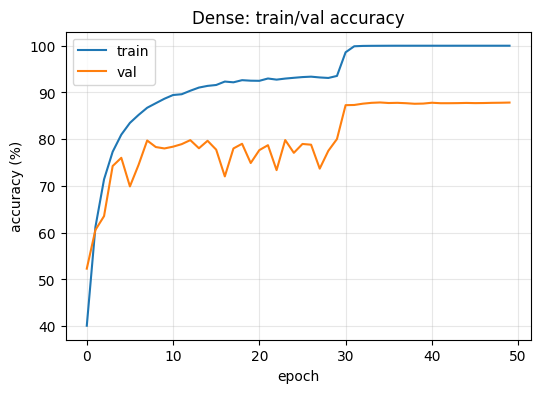

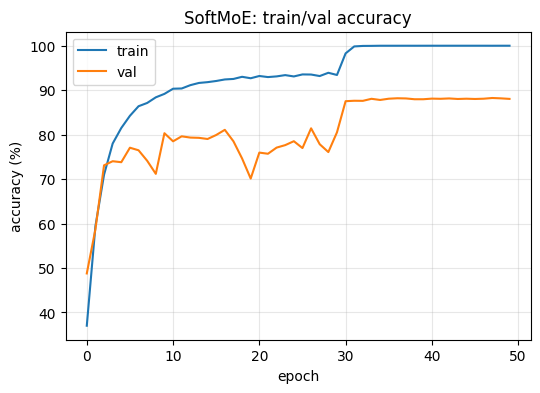

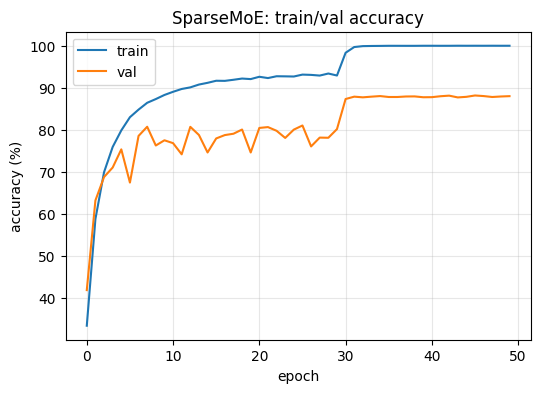

In [16]:
#TRAIN/VAL curves
import matplotlib.pyplot as plt
import numpy as np

for name, h in history.items():
    train_acc = np.array(h["train_acc"])
    val_acc   = np.array(h["val_acc"])

    plt.figure(figsize=(6,4))
    plt.plot(train_acc * 100, label="train")
    plt.plot(val_acc * 100, label="val")
    plt.xlabel("epoch")
    plt.ylabel("accuracy (%)")
    plt.title(f"{name}: train/val accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


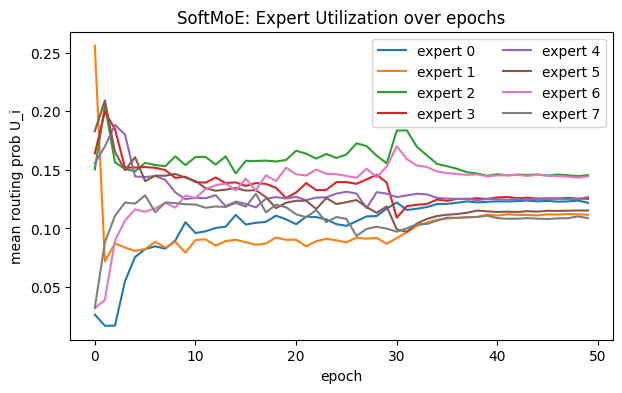

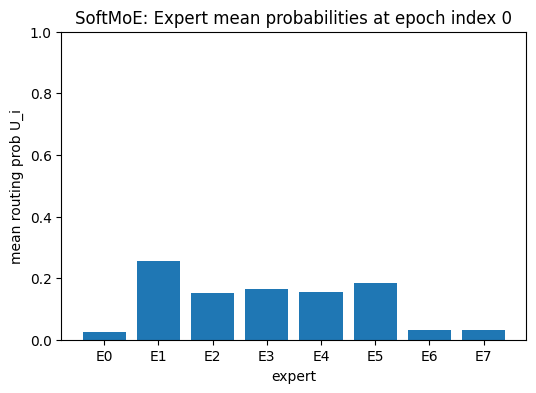

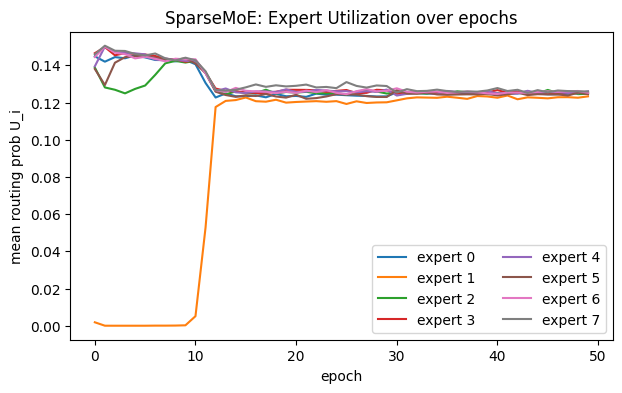

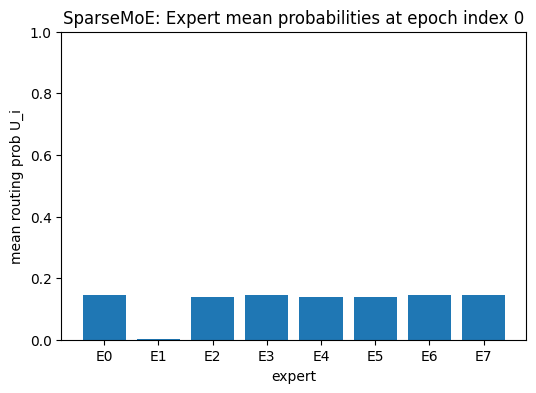

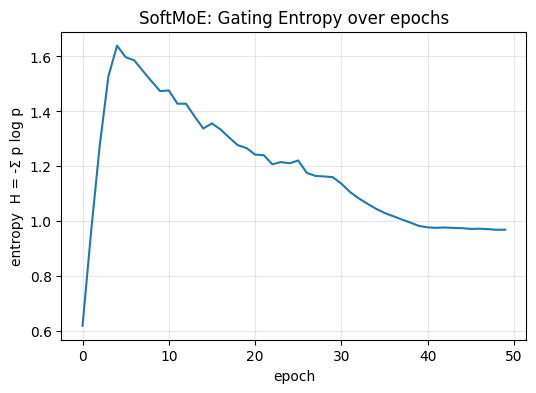

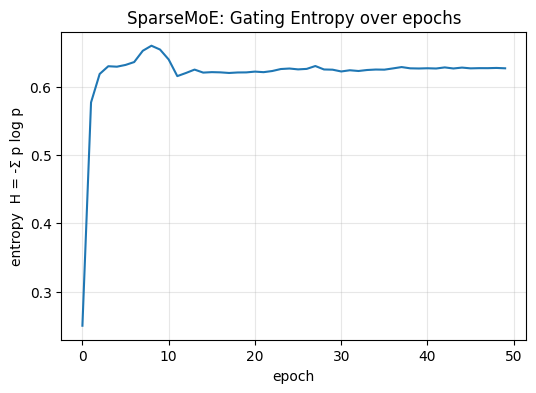

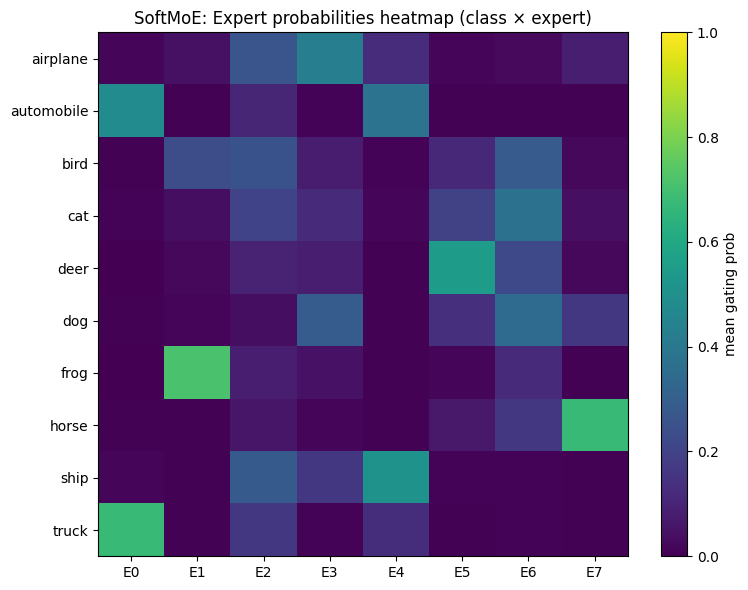

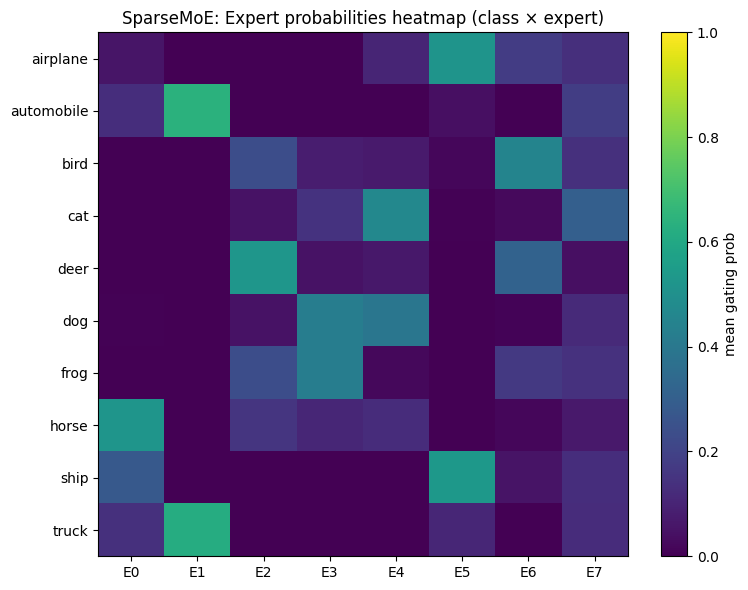

In [17]:
#Gating stats for spars/softmoe
soft_hist   = history["SoftMoE"]
sparse_hist = history["SparseMoE"]

# Expert utilization over epochs
plot_expert_utilization(soft_hist,   ff_layer="SoftMoE")
plot_expert_utilization(sparse_hist, ff_layer="SparseMoE")

# Gating entropy over epochs
plot_gating_entropy(soft_hist,   ff_layer="SoftMoE")
plot_gating_entropy(sparse_hist, ff_layer="SparseMoE")

# If you logged per-class expert probabilities (class_expert_mean)
if "class_expert_mean" in soft_hist:
    plot_expert_probs_heatmap(
        soft_hist["class_expert_mean"],
        class_names=soft_hist.get("class_names", None),
        ff_layer="SoftMoE",
    )

if "class_expert_mean" in sparse_hist:
    plot_expert_probs_heatmap(
        sparse_hist["class_expert_mean"],
        class_names=sparse_hist.get("class_names", None),
        ff_layer="SparseMoE",
    )
